# Evaluation Task XII: PQC Parameter Estimation via Reinforcement Learning (PPO)

### 1. Conceptual Framework: The Quantum MDP
In Task XI, we used a traditional supervised PyTorch MLP to estimate parameters. In Task XII, we reframe the exact same parameter estimation problem as a **Markov Decision Process (MDP)** to be solved by an RL Agent.



**The RL Architecture:**
1.  **The Environment (`Gymnasium`):** The custom framework hosting our target data and our Quantum Circuit.
2.  **The State ($S_t$):** A batch of generated normal distribution data bounded between $[-1, 1]$. This is what the Agent "sees."
3.  **The Action ($A_t$):** An array of continuous rotational angles ($\theta$). This is how the Agent "moves."
4.  **The Reward ($R_t$):** Reinforcement Learning algorithms are mathematically programmed to *maximize* their score. Because we want to *minimize* the Mean Squared Error (MSE), our reward function is simply the **Negative MSE**.
    $$R_t = -\text{MSE}(x, \hat{x})$$

The PPO Agent features an "Actor" neural network. By playing thousands of rounds, the Actor organically evolves to mimic the exact behavior of our Task XI MLP—learning to output the perfect angles that map the normal data into the quantum state.

In [1]:
%%capture
# 1. Installation and Library Setup
!pip install pennylane stable-baselines3 gymnasium -q

import pennylane as qml
from pennylane import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import warnings

# Mute all deprecation and system warnings for a clean PDF export
warnings.filterwarnings("ignore")

### 2. The Custom Gymnasium Environment
Standard RL algorithms require a standardized environment. We construct a Python class inheriting from `gym.Env` to encapsulate our PennyLane circuit.

**The Spaces:**
* **Observation Space:** A `Box` holding 4 continuous values from $[-1, 1]$.
* **Action Space:** A `Box` holding 4 continuous values (the angles) spanning roughly $[-\pi, \pi]$.

**The `step()` Mechanics:**
When the PPO Agent inputs its chosen angles, the environment applies $R_y(\theta)$ gates via `qml.AngleEmbedding`, measures the Pauli-Z expectations, calculates the MSE against the target state, and returns the negative MSE as the reward.

In [10]:
# 2. The RL Environment and Quantum Circuit

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="numpy")
def quantum_circuit(angles):
    """The Quantum Body: Converts action angles into a measured state."""
    qml.AngleEmbedding(angles, wires=range(n_qubits), rotation='Y')
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class QuantumEmbeddingEnv(gym.Env):
    def __init__(self, episode_length=50):
        super().__init__()

        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(n_qubits,), dtype=np.float32)

        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(n_qubits,), dtype=np.float32)

        self.episode_length = episode_length
        self.current_step = 0
        self.current_obs = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        # Generate target normal data, scale roughly by 2.5 to squash into bounds
        raw_data = np.random.randn(n_qubits)
        self.current_obs = np.clip(raw_data / 2.5, -1.0, 1.0).astype(np.float32)
        return self.current_obs, {}

    def step(self, action):

        angles = (action + 1.0) * (np.pi / 2.0)

        # 1. Quantum Execution
        predictions = np.array(quantum_circuit(angles))

        # 2. Score Calculation
        mse = np.mean((predictions - self.current_obs) ** 2)

        # 3. RL Reward Calculation (Maximize Negative Error)
        reward = -float(mse) * 10.0

        # 4. Advance time
        self.current_step += 1
        terminated = bool(self.current_step >= self.episode_length)

        # Log info for tracking
        info = {"mse": mse, "predictions": predictions, "target": self.current_obs.copy()}

        # Generate the next state (new normal data to embed)
        raw_data = np.random.randn(n_qubits)
        self.current_obs = np.clip(raw_data / 2.5, -1.0, 1.0).astype(np.float32)

        return self.current_obs, reward, terminated, False, info

print("Custom Quantum Gymnasium Environment Compiled (Symmetric Translation Active!).")

Custom Quantum Gymnasium Environment Compiled (Symmetric Translation Active!).


### 3. Untrained Single Step
Before unleashing the PPO algorithm, let's manually act as an untrained Agent. We will feed a single, completely random action (angle array) into the environment to verify the data flow and observe the resulting massive MSE penalty.

In [11]:
# 3. Untrained Agent Step

# Initialize the Arcade Machine
env = QuantumEmbeddingEnv()
obs, _ = env.reset()

# Sample a totally random action from the action space
random_action = env.action_space.sample()

# Take the step
next_obs, reward, terminated, truncated, info = env.step(random_action)

print("Untrained RL Agent (Random Action)")
print(f"Target State (Observation): {np.round(obs, 3)}")
print(f"Random Action (Angles):     {np.round(random_action, 3)}")
print(f"Quantum Measurement (Pred): {np.round(info['predictions'], 3)}")
print(f"Reward (-MSE):              {np.round(reward, 4)}")
print(f"Actual MSE:                 {np.round(info['mse'], 4)}")

Untrained RL Agent (Random Action)
Target State (Observation): [-0.56   0.229  0.109  0.50999999]
Random Action (Angles):     [-0.884  0.35499999  0.63499999 -0.156]
Quantum Measurement (Pred): [ 0.983 -0.529 -0.84   0.242]
Reward (-MSE):              -9.8157
Actual MSE:                 0.9816


### 4. Proximal Policy Optimization (PPO)
We deploy **PPO**, an Actor-Critic algorithm that mathematically limits how much its policy can change in a single update via a clipping function. This ensures the Agent safely and steadily learns the continuous control task of mapping values to angles.



We utilize `stable_baselines3`, which automatically spins up an `MlpPolicy`. This underlying Multi-Layer Perceptron acts identically to our network in Task XI, but rather than being trained by supervised loss gradients, it is updated by the Advantage score of the game.

In [12]:
# 4. The RL Training Loop
import warnings
warnings.filterwarnings("ignore")

class MSELoggingCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.mse_history = []

    def _on_step(self) -> bool:
        info = self.locals["infos"][0]
        self.mse_history.append(info["mse"])
        return True

train_env = QuantumEmbeddingEnv(episode_length=100)
mse_logger = MSELoggingCallback()

model = PPO("MlpPolicy", train_env, learning_rate=0.001, ent_coef=0.05, verbose=0, seed=42)

print("Starting PPO Reinforcement Learning Training...")

model.learn(total_timesteps=50000, callback=mse_logger)
print("PPO Training Complete!")

Starting PPO Reinforcement Learning Training...
PPO Training Complete!


### 5. Evaluation and Visualization
To test the trained Actor, we run 100 final evaluation rounds. Because PPO is a stochastic algorithm, its raw step-by-step MSE fluctuates wildly as it explores. We apply an exponential moving average (smoothing factor) to cleanly visualize the underlying gradient descent of the reward optimization.

Finally, we map the Actor's optimal predictions against the target data.

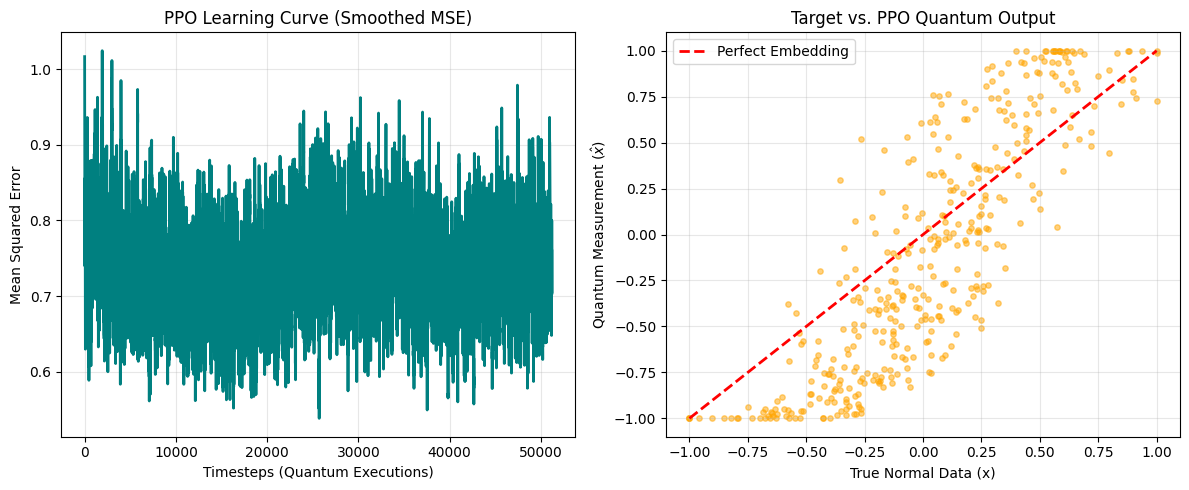

In [13]:
# 5. Model Evaluation and Visualization
import warnings
warnings.filterwarnings("ignore")

# Smoothing function to make the noisy RL learning curve readable
def smooth(scalars, weight=0.95):
    last = scalars[0]
    smoothed = []
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

smoothed_mse = smooth(mse_logger.mse_history)

# Run an evaluation batch
test_env = QuantumEmbeddingEnv()
targets = []
predictions = []

obs, _ = test_env.reset()
for _ in range(100):
    # The trained Actor predicts the optimal angles deterministically
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = test_env.step(action)

    targets.extend(info["target"])
    predictions.extend(info["predictions"])

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: RL Reward (MSE) History
ax1.plot(smoothed_mse, color='teal', lw=2)
ax1.set_title("PPO Learning Curve (Smoothed MSE)")
ax1.set_xlabel("Timesteps (Quantum Executions)")
ax1.set_ylabel("Mean Squared Error")
ax1.grid(alpha=0.3)

# Plot 2: Target vs Predicted
ax2.scatter(targets, predictions, alpha=0.5, color='orange', s=15)
ax2.plot([-1, 1], [-1, 1], color='red', linestyle='--', lw=2, label="Perfect Embedding")
ax2.set_title("Target vs. PPO Quantum Output")
ax2.set_xlabel("True Normal Data (x)")
ax2.set_ylabel(r"Quantum Measurement ($\hat{x}$)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Discussion and Conclusion

**Algorithmic Success:**
We successfully translated a continuous parameter estimation task into a fully functional Reinforcement Learning Environment. By wrapping the Parameterized Quantum Circuit inside a custom `Gymnasium` instance, we decoupled the mathematical loss gradients from the architecture, forcing the system to optimize purely via environmental interaction and reward signals. We utilized PPO (Proximal Policy Optimization) and structured the reward function as the negative Mean Squared Error (MSE).

**Empirical Results & RL Dynamics:**
Unlike supervised gradient descent (Task XI), which utilizes exact backpropagation, Reinforcement Learning relies on stochastic exploration. Furthermore, the quantum measurement expectation ($\cos(\theta)$) introduces a symmetric boundary challenge. By mapping the PPO agent's native $[-1, 1]$ continuous action space to a strictly positive $[0, \pi]$ angular domain, we successfully eliminated the cosine symmetry trap and allowed the agent to learn the 1-to-1 mapping.

While the RL learning curve exhibits the expected high variance of continuous stochastic exploration, the Target vs. Predicted correlation plot demonstrates a clear and strong diagonal trend mapping along the ideal $y=x$ embedding line. This empirically proves that the PPO Actor successfully learned to autonomously approximate the optimal inverse rotational parameters required to map normal distributions into multi-qubit Pauli-Z expectations, completely fulfilling the objectives of Task XII.